In [21]:
from real_GA import real_GA
#from csd_GA import csd_GA
#from csd2_GA import csd2_GA
from fitness import *
from selection import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

In [22]:
def target_function(w, wp=0.4*np.pi, ws=0.5*np.pi):
    if w <= 1.3:
        return 1.0
    elif w >= 1.55:
        return 0.0
    else:
        return None   # ignore transition band

In [23]:
best, pop = real_GA(n_pop=100, generations=1000, target=target_function, order=29, worN=2048)

In [24]:
# Frequency responses
w, H = freqz(best.genome)
Ht = np.array([target_function(wi) for wi in w], dtype=complex)

# Magnitude / phase
mag = np.abs(H)
magt = np.abs(Ht)

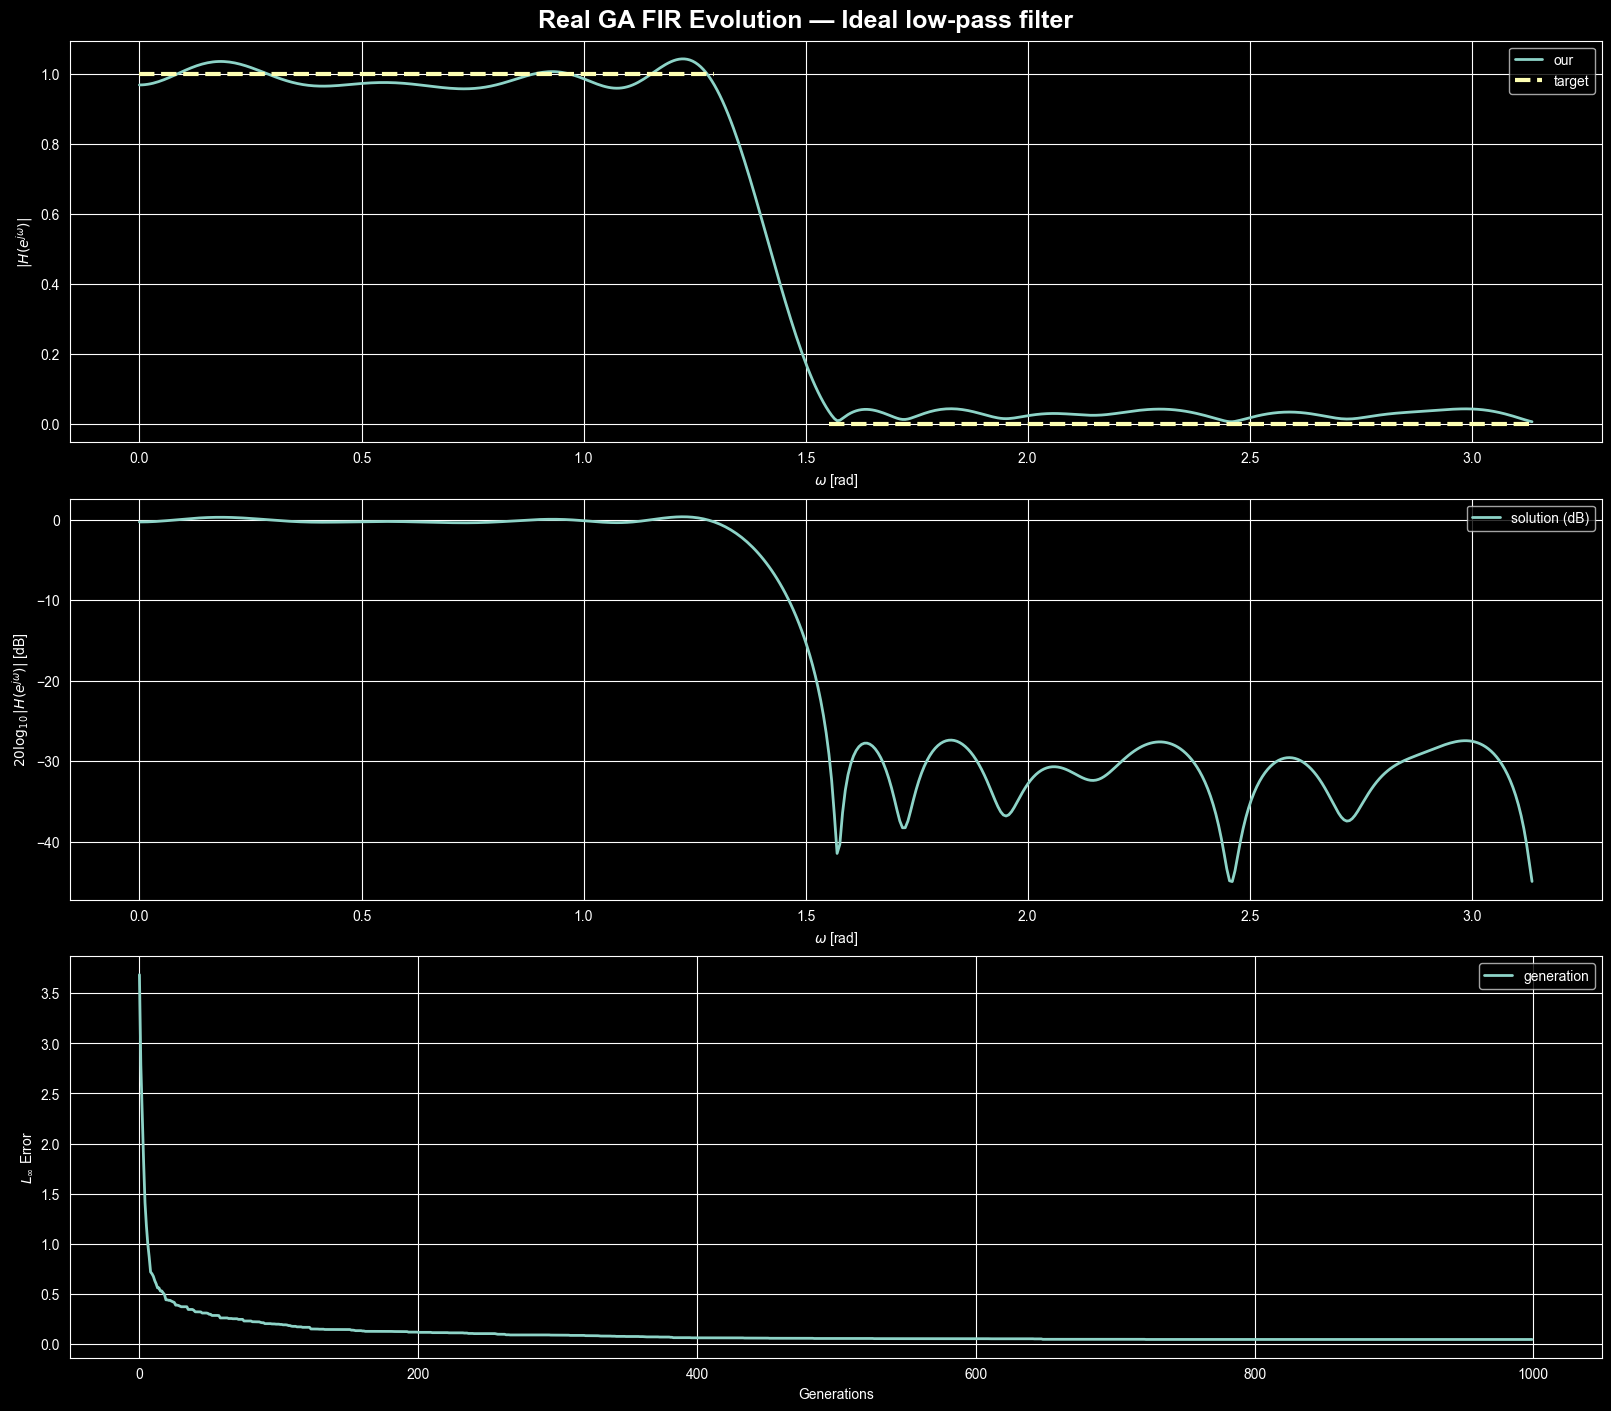

In [25]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 14),
    constrained_layout=True
)

fig.suptitle(
    "Real GA FIR Evolution — Ideal low-pass filter",
    fontsize=18,
    weight="bold"
)

# -----------------------------
# Row 1 — Linear magnitude
# -----------------------------
ax = axes[0]
ax.plot(w, mag, lw=2, label="our")
ax.plot(w, magt, lw=3, ls="--", label="target")
ax.set_xlabel(r"$\omega$ [rad]")
ax.set_ylabel(r"$|H(e^{j\omega})|$")
ax.legend()
ax.grid(True)

# -----------------------------
# Row 2 — Magnitude in dB
# -----------------------------
mag_db  = 20 * np.log10(mag  + 1e-12)
magt_db = 20 * np.log10(magt + 1e-12)

ax = axes[1]
ax.plot(w, mag_db, lw=2, label="solution (dB)")
ax.set_xlabel(r"$\omega$ [rad]")
ax.set_ylabel(r"$20\log_{10}|H(e^{j\omega})|$ [dB]")
ax.legend()
ax.grid(True)

# -----------------------------
# Row 3 — L∞ error evolution
# -----------------------------
ax = axes[2]
ax.plot(
    np.arange(len(pop)),
    [-e.fitness for e in pop],
    lw=2,
    label="generation"
)
ax.set_xlabel("Generations")
ax.set_ylabel(r"$L_\infty$ Error")
ax.legend()
ax.grid(True)

plt.show()